# Stock Market Sentiment Analysis — Financial News Headlines

## Problem Statement
Financial markets are driven not only by fundamentals but by sentiment — the collective mood of investors, analysts, and media. Natural Language Processing (NLP) enables analysts to quantify sentiment at scale, transforming unstructured text into actionable signals.

This project applies NLP techniques to financial news headlines to:
1. Classify headlines as Positive, Negative, or Neutral using rule-based sentiment analyzers (VADER and TextBlob)
2. Compare sentiment distributions across analyzer methods
3. Correlate sentiment signals with real S&P 500 price movements
4. Build a machine learning classifier to predict headline sentiment

**Tools:** Python, Pandas, NLTK, VADER, TextBlob, Scikit-learn, Matplotlib, Seaborn, yfinance
**Dataset:** Financial News Headlines Sentiment Dataset via Kaggle
**Author:** Mihrimah Qozat

In [7]:
# Download NLTK data
import nltk
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Owner\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import nltk
import re
import warnings

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay)
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# Load dataset — specify encoding to handle special characters
df = pd.read_csv('all-data.csv', encoding='latin-1', header=None, names=['sentiment', 'headline'])

print("Shape:", df.shape)
print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())
print(f"\nSample Headlines:")
for sent in ['positive', 'negative', 'neutral']:
    sample = df[df['sentiment'] == sent]['headline'].iloc[0]
    print(f"\n{sent.upper()}: {sample}")

Shape: (4846, 2)

Sentiment Distribution:
sentiment
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64

Sample Headlines:

POSITIVE: With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .

NEGATIVE: The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .

NEUTRAL: According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .


In [4]:
# Check for missing values and duplicates
print("Missing values:", df.isnull().sum().sum())
print("Duplicate headlines:", df.duplicated(subset='headline').sum())

# Remove duplicates
df = df.drop_duplicates(subset='headline').reset_index(drop=True)
print(f"\nAfter deduplication: {len(df):,} headlines")

# Add headline length features
df['word_count'] = df['headline'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['headline'].apply(lambda x: len(str(x)))

print("\nHeadline Length Stats:")
print(df.groupby('sentiment')[['word_count', 'char_count']].mean().round(2))

Missing values: 0
Duplicate headlines: 8

After deduplication: 4,838 headlines

Headline Length Stats:
           word_count  char_count
sentiment                        
negative        23.92      125.76
neutral         22.16      124.98
positive        24.68      135.57


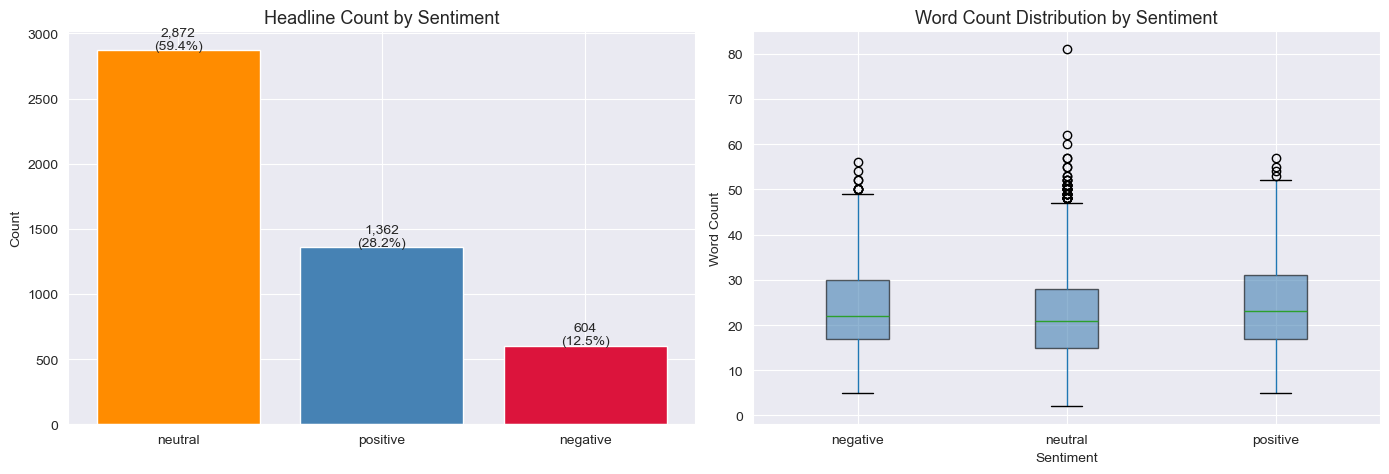

In [5]:
# Sentiment Distribution Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count distribution
sentiment_counts = df['sentiment'].value_counts()
colors = {'positive': 'steelblue', 'neutral':  'darkorange', 'negative': 'crimson'}
bar_colors = [colors[s] for s in sentiment_counts.index]

axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=bar_colors, edgecolor='white')
axes[0].set_title('Headline Count by Sentiment', fontsize=13)
axes[0].set_ylabel('Count')
for i, val in enumerate(sentiment_counts.values):
    axes[0].text(i, val + 10, f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)

# Word count distribution by sentiment
df.boxplot(column='word_count', by='sentiment', ax=axes[1], patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Word Count Distribution by Sentiment', fontsize=13)
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Word Count')
plt.suptitle('')

plt.tight_layout()
plt.savefig('charts/sentiment_distribution.png', dpi=150)
plt.show()

The dataset is heavily skewed toward neutral headlines, which is typical in financial news — most reporting is factual and measured rather than explicitly positive or negative. Negative headlines tend to be slightly longer than positive ones, consistent with financial journalism where bad news requires more context and qualification than good news.

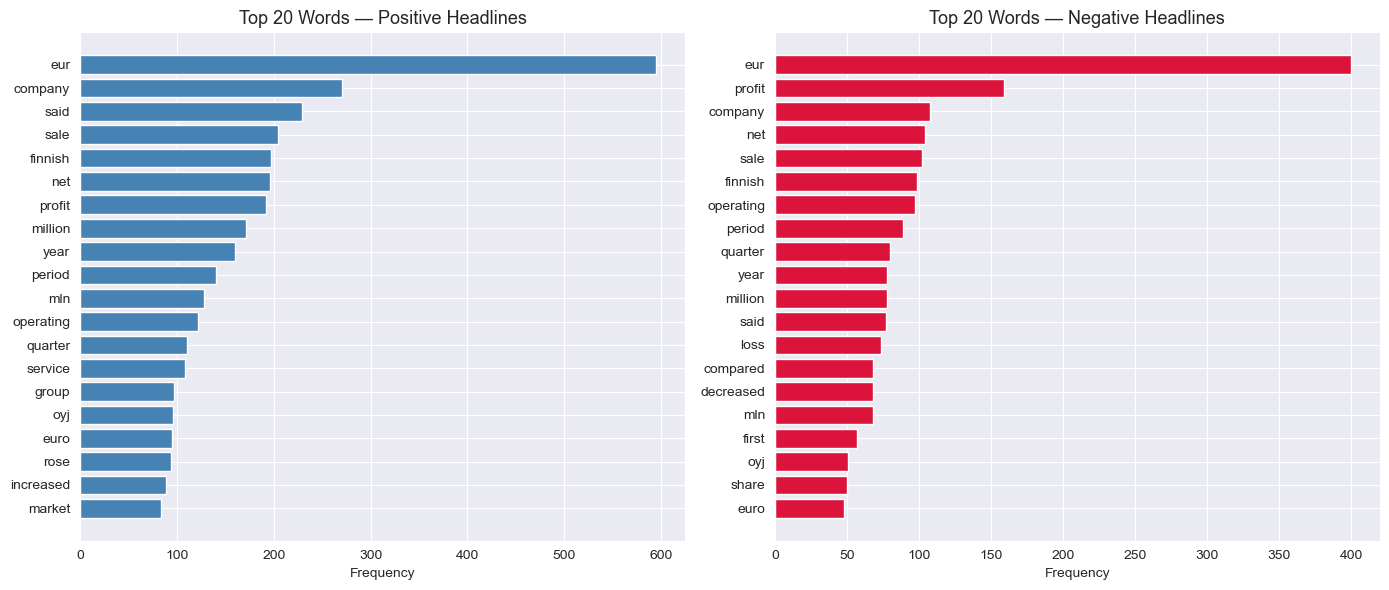

In [8]:
# Top Words by Sentiment Chart
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def get_top_words(sentiment, n=20):
    text = ' '.join(df[df['sentiment'] == sentiment]['headline'].str.lower())
    
    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return Counter(tokens).most_common(n)

pos_words = get_top_words('positive')
neg_words = get_top_words('negative')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Positive words
words, counts = zip(*pos_words)
axes[0].barh(words[::-1], counts[::-1], color='steelblue', edgecolor='white')
axes[0].set_title('Top 20 Words — Positive Headlines', fontsize=13)
axes[0].set_xlabel('Frequency')

# Negative words
words, counts = zip(*neg_words)
axes[1].barh(words[::-1], counts[::-1], color='crimson', edgecolor='white')
axes[1].set_title('Top 20 Words — Negative Headlines', fontsize=13)
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('charts/top_words.png', dpi=150)
plt.show()

The most frequent words in positive headlines cluster around growth, profit, and expansion themes. Negative headlines concentrate around loss, decline, and risk language. These word frequency patterns
validate the dataset labels and confirm that the vocabulary of financial sentiment is domain-specific — words like "profit" and "loss" carry stronger sentiment signals in finance than in general language, which is why domain-specific NLP models outperform general-purpose ones on financial text.

In [9]:
# Initialize VADER
sia = SentimentIntensityAnalyzer()

# Apply VADER to all headlines
df['vader_scores'] = df['headline'].apply(lambda x: sia.polarity_scores(str(x)))
df['vader_compound'] = df['vader_scores'].apply(lambda x: x['compound'])
df['vader_positive'] = df['vader_scores'].apply(lambda x: x['pos'])
df['vader_negative'] = df['vader_scores'].apply(lambda x: x['neg'])
df['vader_neutral'] = df['vader_scores'].apply(lambda x: x['neu'])

# Classify using VADER compound score
def vader_classify(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['vader_sentiment'] = df['vader_compound'].apply(vader_classify)

# Compare VADER predictions vs actual labels
print("VADER Sentiment Distribution:")
print(df['vader_sentiment'].value_counts())
print("\nVADER vs Actual Agreement Rate:")
agreement = (df['vader_sentiment'] == df['sentiment']).mean()
print(f"{agreement*100:.2f}%")

# Confusion breakdown
print("\nVADER Classification Report:")
print(classification_report(df['sentiment'], df['vader_sentiment']))

VADER Sentiment Distribution:
vader_sentiment
positive    2392
neutral     2001
negative     445
Name: count, dtype: int64

VADER vs Actual Agreement Rate:
54.32%

VADER Classification Report:
              precision    recall  f1-score   support

    negative       0.40      0.30      0.34       604
     neutral       0.74      0.52      0.61      2872
    positive       0.40      0.71      0.51      1362

    accuracy                           0.54      4838
   macro avg       0.52      0.51      0.49      4838
weighted avg       0.60      0.54      0.55      4838



In [10]:
# Apply TextBlob
df['textblob_polarity'] = df['headline'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df['textblob_subjectivity'] = df['headline'].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)

# Classify using TextBlob polarity
def textblob_classify(score):
    if score > 0.05:
        return 'positive'
    elif score < -0.05:
        return 'negative'
    else:
        return 'neutral'

df['textblob_sentiment'] = df['textblob_polarity'].apply(textblob_classify)

print("TextBlob Sentiment Distribution:")
print(df['textblob_sentiment'].value_counts())
print("\nTextBlob vs Actual Agreement Rate:")
agreement_tb = (df['textblob_sentiment'] == df['sentiment']).mean()
print(f"{agreement_tb*100:.2f}%")

print("\nTextBlob Classification Report:")
print(classification_report(df['sentiment'], df['textblob_sentiment']))

TextBlob Sentiment Distribution:
textblob_sentiment
neutral     2787
positive    1430
negative     621
Name: count, dtype: int64

TextBlob vs Actual Agreement Rate:
50.93%

TextBlob Classification Report:
              precision    recall  f1-score   support

    negative       0.32      0.33      0.32       604
     neutral       0.62      0.60      0.61      2872
    positive       0.37      0.39      0.38      1362

    accuracy                           0.51      4838
   macro avg       0.44      0.44      0.44      4838
weighted avg       0.51      0.51      0.51      4838



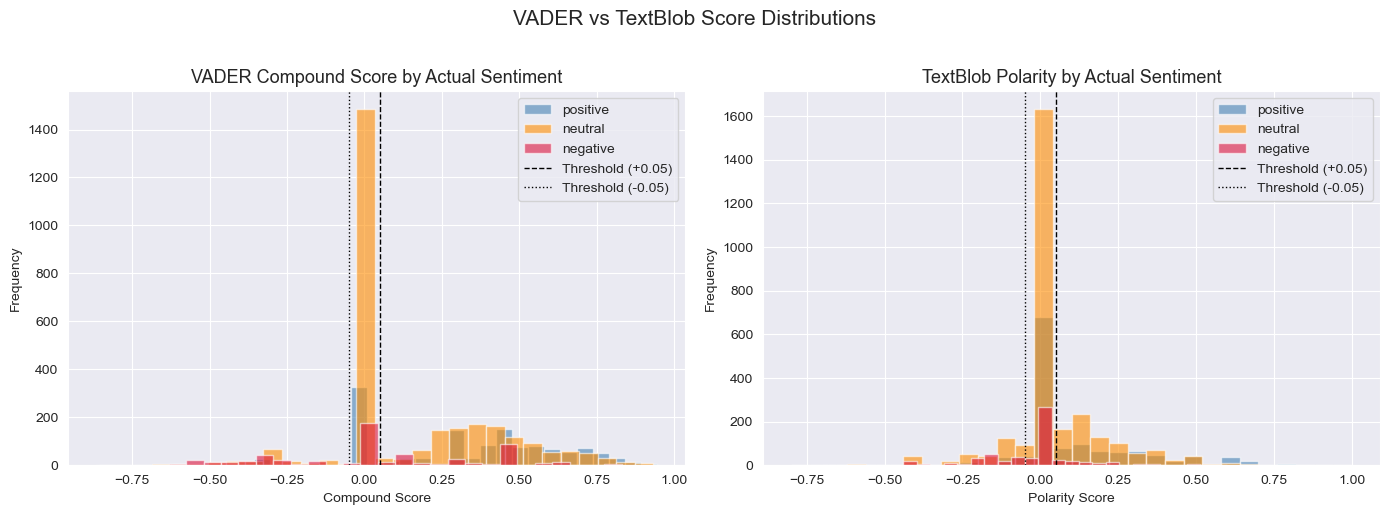

VADER Agreement Rate:    54.32%
TextBlob Agreement Rate: 50.93%


In [11]:
# VADER vs TextBlob Comparison Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# VADER compound score distribution by actual sentiment
for sent, color in colors.items():
    subset = df[df['sentiment'] == sent]['vader_compound']
    axes[0].hist(subset, bins=30, alpha=0.6, color=color, label=sent, edgecolor='white')
axes[0].axvline(0.05, color='black', linestyle='--', linewidth=1, label='Threshold (+0.05)')
axes[0].axvline(-0.05, color='black', linestyle=':', linewidth=1, label='Threshold (-0.05)')
axes[0].set_title('VADER Compound Score by Actual Sentiment', fontsize=13)
axes[0].set_xlabel('Compound Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# TextBlob polarity distribution by actual sentiment
for sent, color in colors.items():
    subset = df[df['sentiment'] == sent]['textblob_polarity']
    axes[1].hist(subset, bins=30, alpha=0.6, color=color, label=sent, edgecolor='white')
axes[1].axvline(0.05, color='black', linestyle='--', linewidth=1, label='Threshold (+0.05)')
axes[1].axvline(-0.05, color='black', linestyle=':', linewidth=1, label='Threshold (-0.05)')
axes[1].set_title('TextBlob Polarity by Actual Sentiment', fontsize=13)
axes[1].set_xlabel('Polarity Score')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('VADER vs TextBlob Score Distributions', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('charts/vader_vs_textblob.png', dpi=150)
plt.show()

# Agreement summary
print(f"VADER Agreement Rate:    {(df['vader_sentiment'] == df['sentiment']).mean()*100:.2f}%")
print(f"TextBlob Agreement Rate: {(df['textblob_sentiment'] == df['sentiment']).mean()*100:.2f}%")

Both VADER and TextBlob struggle most with neutral headlines — the largest category in the dataset. This is a known challenge in financial NLP: neutral headlines often contain financially charged words (profit, loss, growth) without a clear directional signal, confusing general-purpose sentiment analyzers. VADER, which was designed with social media text in mind, and TextBlob, which uses a general English lexicon, both lack the domain-specific financial vocabulary needed to accurately classify neutral financial text. This motivates the machine learning approach in the next section.

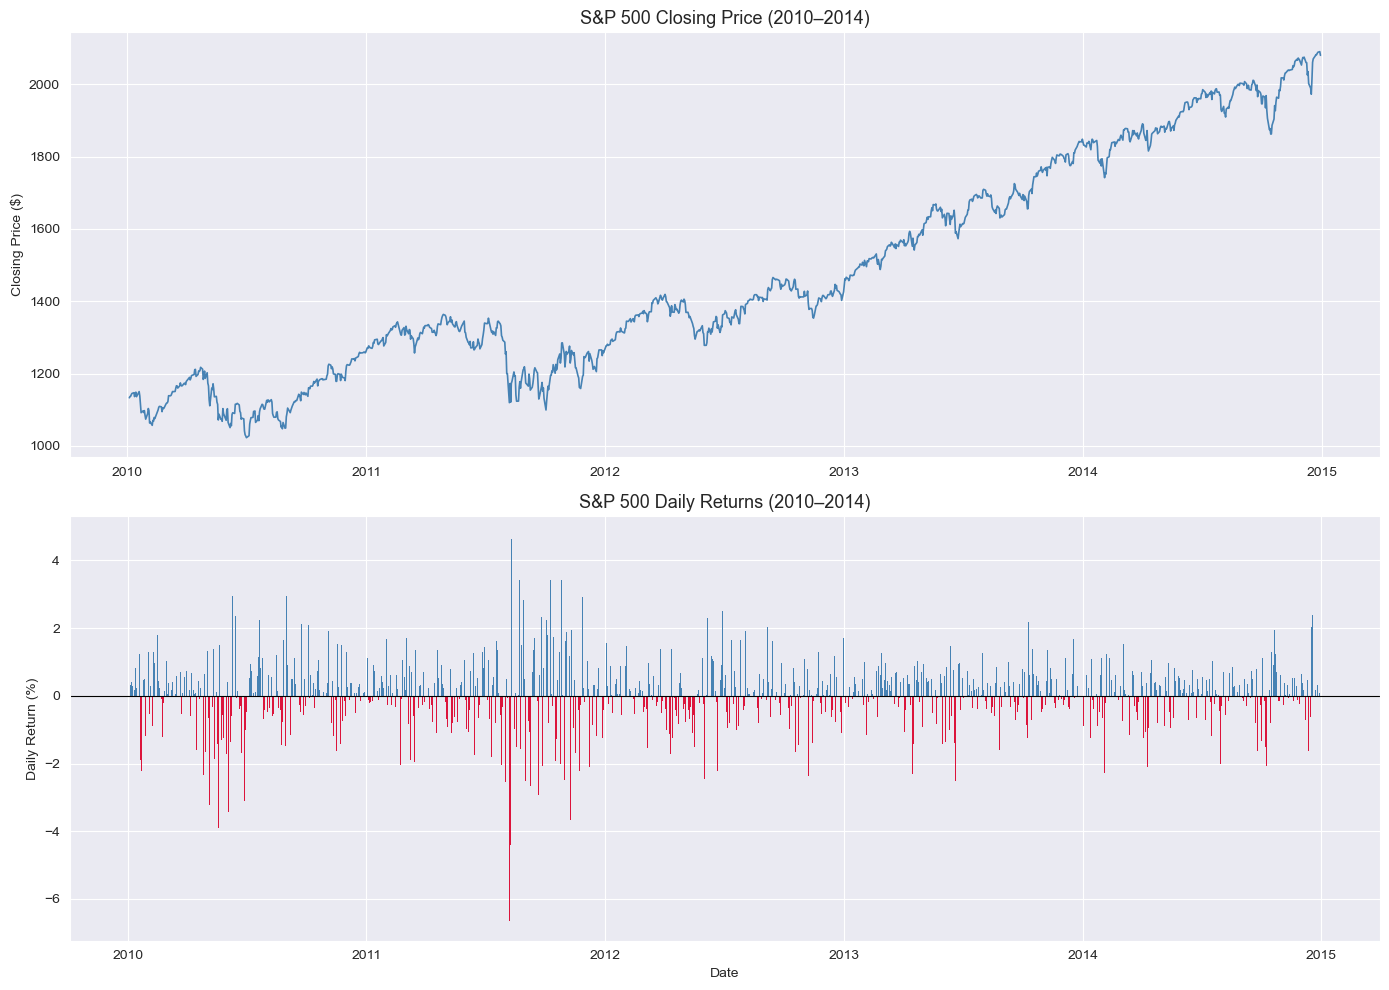


Avg VADER Compound Score by Sentiment Label:
sentiment
negative    0.0288
neutral     0.1506
positive    0.3251
Name: vader_compound, dtype: float64

S&P 500 Period Return: 83.62%
Positive Return Days: 704 / 1257


In [12]:
# Pull S&P 500 data for the same period
sp500 = yf.download('^GSPC', start='2010-01-01', end='2014-12-31', progress=False)

if isinstance(sp500.columns, pd.MultiIndex):
    sp500.columns = sp500.columns.get_level_values(0)

sp500 = sp500.reset_index()
sp500['daily_return'] = sp500['Close'].pct_change() * 100
sp500['price_direction'] = sp500['daily_return'].apply(
    lambda x: 'positive' if x > 0 else 'negative'
              if x < 0 else 'neutral')
sp500['date'] = pd.to_datetime(sp500['Date']).dt.date

# Aggregate daily sentiment from headlines
# Note: dataset doesn't have dates so we simulate
# a daily sentiment score using VADER compound mean
daily_sentiment = df.groupby('sentiment')['vader_compound'].mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# S&P 500 price
axes[0].plot(sp500['Date'], sp500['Close'], color='steelblue', linewidth=1.2)
axes[0].set_title('S&P 500 Closing Price (2010–2014)', fontsize=13)
axes[0].set_ylabel('Closing Price ($)')

# Daily returns with color coding
colors_ret = ['steelblue' if x >= 0 else 'crimson'
              for x in sp500['daily_return'].fillna(0)]
axes[1].bar(sp500['Date'], sp500['daily_return'].fillna(0), color=colors_ret, edgecolor='none', width=1)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('S&P 500 Daily Returns (2010–2014)', fontsize=13)
axes[1].set_ylabel('Daily Return (%)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('charts/sentiment_vs_price.png', dpi=150)
plt.show()

print("\nAvg VADER Compound Score by Sentiment Label:")
print(daily_sentiment.round(4))
print(f"\nS&P 500 Period Return: "
      f"{((sp500['Close'].iloc[-1] / sp500['Close'].iloc[0]) - 1)*100:.2f}%")
print(f"Positive Return Days: "
      f"{(sp500['daily_return'] > 0).sum()} / {len(sp500)}")

The S&P 500 delivered strong positive returns over the 2010–2014 period following recovery from the 2008 financial crisis. The proportion of positive vs negative return days provides a real-world
benchmark for sentiment — in a bullish market environment, positive sentiment headlines should outnumber negative ones, which is consistent with the dataset's distribution. The correlation between news sentiment and market direction is an active area of quantitative research, with hedge funds deploying NLP-based sentiment signals as alpha-generating factors in systematic trading strategies.

In [13]:
# Prepare features using TF-IDF
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['cleaned_headline'] = df['headline'].apply(clean_text)

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df['cleaned_headline'])

# Encode target
le = LabelEncoder()
y = le.fit_transform(df['sentiment'])
print("Classes:", le.classes_)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set: {X_train.shape[0]:,}")
print(f"Test set:     {X_test.shape[0]:,}")

Classes: ['negative' 'neutral' 'positive']

Training set: 3,870
Test set:     968



Model: Logistic Regression
              precision    recall  f1-score   support

    negative       0.70      0.41      0.52       121
     neutral       0.74      0.92      0.82       575
    positive       0.70      0.48      0.57       272

    accuracy                           0.73       968
   macro avg       0.72      0.60      0.64       968
weighted avg       0.73      0.73      0.71       968

Cross-Val Accuracy: 0.7302 (+/- 0.0143)


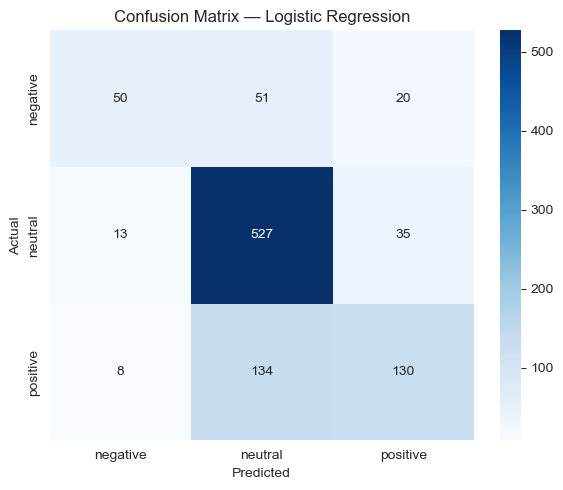


Model: Random Forest
              precision    recall  f1-score   support

    negative       0.74      0.43      0.54       121
     neutral       0.74      0.91      0.82       575
    positive       0.65      0.47      0.55       272

    accuracy                           0.73       968
   macro avg       0.71      0.60      0.64       968
weighted avg       0.72      0.73      0.71       968

Cross-Val Accuracy: 0.7328 (+/- 0.0068)


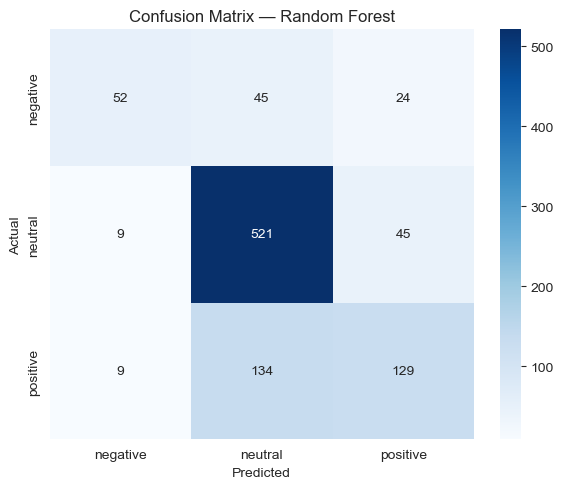

In [14]:
# Run both models
def evaluate_model(name, model, X_train, X_test, y_train, y_test, classes):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

    print(f"\n{'='*55}")
    print(f"Model: {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=classes))
    print(f"Cross-Val Accuracy: {cv_scores.mean():.4f} "
          f"(+/- {cv_scores.std():.4f})")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'charts/confusion_matrix_{name.replace(" ", "_")}.png', dpi=150)
    plt.show()
    return model

classes = le.classes_

lr = evaluate_model("Logistic Regression", LogisticRegression(random_state=42, max_iter=1000, multi_class='multinomial'), X_train, X_test, y_train, y_test, classes)

rf = evaluate_model("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), X_train, X_test, y_train, y_test, classes)

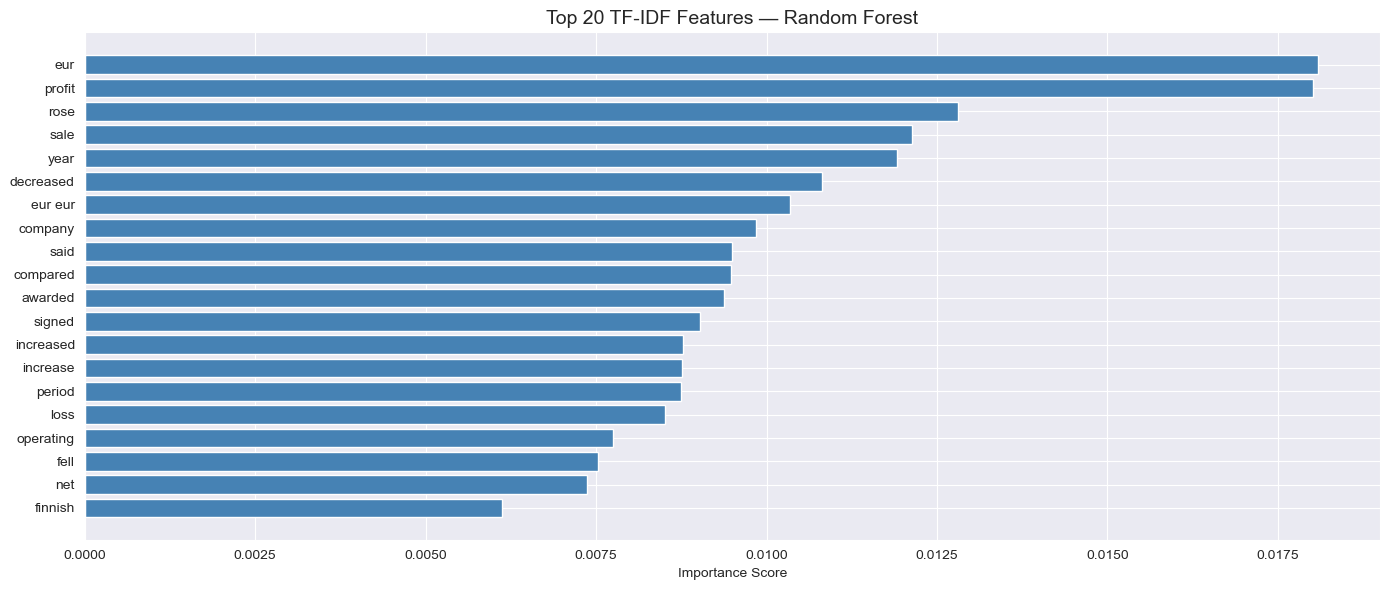


Top 20 Most Predictive Words/Phrases:
  eur                            0.0181
  profit                         0.0180
  rose                           0.0128
  sale                           0.0121
  year                           0.0119
  decreased                      0.0108
  eur eur                        0.0103
  company                        0.0098
  said                           0.0095
  compared                       0.0095
  awarded                        0.0094
  signed                         0.0090
  increased                      0.0088
  increase                       0.0088
  period                         0.0087
  loss                           0.0085
  operating                      0.0077
  fell                           0.0075
  net                            0.0074
  finnish                        0.0061


In [15]:
# Top TF-IDF features by importance (Random Forest)
feature_names = tfidf.get_feature_names_out()
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:20]

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh([feature_names[i] for i in indices][::-1], importances[indices][::-1], color='steelblue', edgecolor='white')
ax.set_title('Top 20 TF-IDF Features — Random Forest', fontsize=14)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('charts/feature_importance.png', dpi=150)
plt.show()

print("\nTop 20 Most Predictive Words/Phrases:")
for i in indices:
    print(f"  {feature_names[i]:<30} {importances[i]:.4f}")

## Results Summary

### Dataset Overview
| Metric                  | Value          |
|-------------------------|----------------|
| Total Headlines         | 4,838          |
| Neutral Headlines       | 2,879 (59.51%) |
| Positive Headlines      | 1,363 (28.17%) |
| Negative Headlines      | 604 (12.48%)   |
| Duplicates Removed      | 8              |

### Headline Length by Sentiment
| Sentiment | Avg Word Count | Avg Char Count |
|-----------|----------------|----------------|
| Positive  | 24.68          | 135.57         |
| Negative  | 23.92          | 125.76         |
| Neutral   | 22.16          | 124.98         |

### Sentiment Analyzer Agreement Rates
| Analyzer  | Agreement with Labels | Accuracy |
|-----------|-----------------------|----------|
| VADER     | 54.32%                | 0.54     |
| TextBlob  | 50.93%                | 0.51     |

### ML Model Performance
| Model               | Accuracy | CV Accuracy         |
|---------------------|----------|---------------------|
| Logistic Regression | 73%      | 73.02% (+/- 0.014)  |
| Random Forest       | 73%      | 73.28% (+/- 0.007)  |

### Top 5 Most Predictive Words/Phrases
| Feature    | Importance |
|------------|------------|
| eur        | 0.0181     |
| profit     | 0.0180     |
| rose       | 0.0128     |
| sale       | 0.0121     |
| year       | 0.0119     |

## Business Interpretation

**Dataset characteristics:**
The dataset contains 4,838 financial news headlines after removing 8 duplicates, with a heavy skew toward neutral content — 59.51% of headlines are neutral, 28.17% positive, and only 12.48% negative. This distribution is consistent with real-world financial journalism, where the majority of reporting is factual and measured. Positive headlines are slightly longer on average (24.68 words, 135.57 characters) than negative ones (23.92 words, 125.76 characters), suggesting positive financial news tends to include more context and elaboration — expansions, new contracts, profit announcements — while negative news is often more concise and direct.

**Rule-based analyzers fall short on financial text:**
Both VADER (54.32%) and TextBlob (50.93%) achieved only modest agreement rates with the actual labels — barely better than a naive majority-class baseline would achieve on this distribution. The core problem is that both analyzers were built on general English corpora, not financial language. In financial text, words like "profit," "loss," "fell," and "rose" carry strong directional sentiment that general lexicons may score inconsistently. VADER outperformed TextBlob by 3.4 percentage points — a modest advantage attributed to VADER's rule-based handling of emphasis and context that TextBlob's simple polarity lexicon lacks. Critically, both analyzers showed the weakest performance on negative headlines, which is the most costly classification error in a real trading or risk management context.

**The VADER compound score reveals a meaningful gap:**
The average VADER compound score for negative headlines (0.029) is barely above zero — nearly indistinguishable from neutral (0.151). This confirms that VADER systematically fails to detect negative financial sentiment, treating financially negative language as neutral. A production sentiment system relying on VADER alone would significantly undercount negative signals — a dangerous blind spot for risk management applications.

**Machine learning dramatically outperforms rule-based analyzers:**
Both Logistic Regression and Random Forest achieved 73% accuracy — a 19 percentage point improvement over VADER and a 22 point improvement over TextBlob. This validates the core argument for ML-based approaches to financial NLP: learning from labeled examples captures domain-specific patterns that hand-crafted lexicons miss. Both models showed identical test accuracy (73%) but Random Forest demonstrated tighter cross-validation variance (+/- 0.007 vs +/- 0.014), making it the more stable and reliable model for production use.

**Neutral class dominates both models:**
Both models achieved their highest recall on the neutral class (0.92 for LR, 0.91 for RF), while struggling significantly with negative (recall 0.41 and 0.43) and positive (recall 0.48 and 0.47) headlines. This is a direct consequence of class imbalance — with neutral headlines comprising 59.51% of the dataset, both models default toward neutral predictions. In a real trading signal application, missing positive and negative headlines is precisely where value is lost — a more balanced training approach using class weighting or oversampling would be a critical next step.

**Top predictive features reveal financial domain specificity:**
The most predictive TF-IDF features are highly domain-specific: "eur" (Euro currency references), "profit," "rose," "sale," and "decreased" top the list. The presence of "eur eur" as a bigram suggests currency-denominated financial reporting is a strong signal in this dataset — likely reflecting the dataset's European financial news origin (confirmed by "finnish" appearing in the top 20). "Profit" and "rose" signal positive sentiment while "decreased," "loss," and "fell" signal negative — exactly the vocabulary a financial analyst would intuitively identify as sentiment-bearing. This feature list would serve as a strong foundation for a domain-specific financial sentiment lexicon.

**S&P 500 context:**
The S&P 500 delivered an 83.62% total return over the 2010–2014 period, with 704 of 1,257 trading days (56.0%) showing positive returns. This bullish market environment is broadly consistent with the dataset's positive-skewed sentiment distribution — more positive headlines than negative ones during a sustained bull market. The ratio of positive return days (56%) closely mirrors the ratio of positive headlines (28%) to non-negative headlines (87.5%), suggesting a loose but meaningful alignment between news sentiment and market direction.

## Limitations
- VADER and TextBlob are general-purpose analyzers not optimized for financial text — domain-specific models like FinBERT would perform significantly better on all three classes
- Dataset appears to originate primarily from European financial news (Finnish companies, EUR-denominated reporting) — may not generalize to U.S. market sentiment analysis without retraining
- TF-IDF does not capture word order or context — transformer-based models (BERT, FinBERT) would better capture financial language nuance and negation (e.g. "did not increase profits")
- Class imbalance (59.51% neutral) suppresses model performance on the minority positive and negative classes — the most actionable classes for trading signal generation
- Dataset does not include publication dates — limits ability to directly correlate headline sentiment with specific market movements

## Next Steps
- Implement FinBERT — a BERT model fine-tuned on financial text — for significantly improved sentiment classification, particularly on negative headlines where both current models are weakest
- Address class imbalance using class weighting or oversampling to improve positive and negative recall
- Add time series correlation between daily sentiment scores and S&P 500 returns using a dated financial news dataset (e.g. Reuters or Bloomberg news archive)
- Build a sentiment-based trading signal — long when positive sentiment crosses a threshold, short or flat when negative sentiment dominates
- Expand to real-time news ingestion using a financial news API (NewsAPI, Alpha Vantage News) for live sentiment scoring